<a href="https://colab.research.google.com/github/Asuskf/from-nlp-to-agents/blob/embeddings/embeddings/embeddings_pipeline_clinico/lab_embeddings_pipeline_clinico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Lab: Algoritmos de Similitud y Pipeline de Evaluación de Embeddings

### *El Pipeline Clínico — de "adivinar el modelo" a "probarlo matemáticamente"*

> **Cómo usar este notebook:** ejecuta las celdas **en orden** con `Shift + Enter`.
> Está pensado para **Google Colab** (los modelos se descargan de Hugging Face la primera vez, tarda ~1–2 min).

---

## ¿Qué vas a resolver?

No todos los espacios vectoriales son iguales. Vas a atacar el problema de la **"ceguera de dominio"**:
demostrar *cuantitativamente* por qué un modelo de embeddings **de propósito general** falla al separar
jerga clínica del ruido, y por qué un modelo **especializado (PubMedBERT)** es la topología geométrica
correcta para un clasificador médico.

### Lo que construiremos (pipeline completo)

| Nivel | Bloque | Qué aprendes |
|------|--------|--------------|
| 0 | **Matemática de la validación** | Similitud coseno, distancia euclídea, dot product |
| 1 | **Carga de modelos** | `sentence-transformers` + Hugging Face |
| 2 | **Golden Dataset** | Datos con *ground truth* y distractores léxicos |
| 3 | **¿Qué es un embedding?** | Forma, dimensión y determinismo de los vectores |
| 4 | **Métricas de distancia** | Comparar 3 métricas sobre vectores reales |
| 5 | **Pipeline de validación** | Margen de Separación generalizado a N docs |
| 6 | **Visualización** | Ver los clústeres con PCA |
| 7 | **Tests automáticos** ✅ | Verificar que el pipeline es correcto |
| 8 | **Clasificador real** | Usar los embeddings para predecir clases nuevas |

### La métrica clave: **Margen de Separación**

$$\text{Margin} = \underbrace{\overline{\cos(\theta_{\text{intra}})}}_{\text{Med vs Med (alto)}} - \underbrace{\overline{\cos(\theta_{\text{inter}})}}_{\text{Med vs Tech (bajo)}}$$

El modelo con **mayor margen** es la arquitectura correcta.


## 0 · Setup

Instalamos las dependencias. En Colab esto tarda un poco la primera vez.

In [1]:
# En Colab, descomenta la siguiente línea la primera vez:
!pip install -q sentence-transformers scikit-learn matplotlib numpy

print("✅ Dependencias listas.")

✅ Dependencias listas.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA

# Reproducibilidad
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("✅ Imports base cargados.")

✅ Imports base cargados.


## 1 · La matemática de la validación (Nivel 0)

Antes de tocar un modelo, entendamos **cómo se mide la cercanía entre dos vectores**.
Un embedding es solo un punto en un espacio de muchas dimensiones. Tenemos 3 formas clásicas de comparar dos puntos:

**1. Similitud Coseno** — mide el *ángulo*. Ignora la magnitud, solo importa la dirección.
$$\cos(\theta) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert} \in [-1, 1]$$
`1` = misma dirección · `0` = perpendiculares (sin relación) · `-1` = opuestos.

**2. Distancia Euclídea** — la distancia "en línea recta". `0` = idénticos, crece sin límite.

**3. Dot Product** — el producto punto crudo (mezcla ángulo *y* magnitud).

En NLP se usa **coseno** casi siempre, porque nos importa el *significado* (dirección), no cuán "largo"
sea el vector. Implementémoslas desde cero para no tratarlas como una caja negra.

In [3]:
def cosine_sim(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def euclidean(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return float(np.linalg.norm(a - b))

def dot_product(a, b):
    return float(np.dot(a, b))

# --- Intuición con vectores de juguete en 2D ---
v_perro   = [1.0, 0.0]   # apunta a la derecha
v_lobo    = [0.9, 0.1]   # casi la misma dirección  -> relacionado
v_avion   = [0.0, 1.0]   # perpendicular            -> sin relación

print("perro vs lobo  (relacionados):")
print(f"   coseno    = {cosine_sim(v_perro, v_lobo):.4f}   (cerca de 1  ✅)")
print(f"   euclídea  = {euclidean(v_perro, v_lobo):.4f}   (cerca de 0  ✅)")
print()
print("perro vs avión (NO relacionados):")
print(f"   coseno    = {cosine_sim(v_perro, v_avion):.4f}   (cerca de 0  ✅)")
print(f"   euclídea  = {euclidean(v_perro, v_avion):.4f}   (grande      ✅)")

perro vs lobo  (relacionados):
   coseno    = 0.9939   (cerca de 1  ✅)
   euclídea  = 0.1414   (cerca de 0  ✅)

perro vs avión (NO relacionados):
   coseno    = 0.0000   (cerca de 0  ✅)
   euclídea  = 1.4142   (grande      ✅)


## 2 · Cargar los espacios latentes (Nivel 1)

Cargamos **dos** modelos pre-entrenados. Ambos convierten texto → vector, pero fueron entrenados
con datos muy distintos, así que su geometría interna es diferente.

- **Modelo A — General:** `all-MiniLM-L6-v2`. Entrenado con web genérica (Wikipedia, Reddit…). Rápido y popular.
- **Modelo B — Médico:** `pritamdeka/S-PubMedBert-MS-MARCO`. Entrenado con PubMed y notas clínicas.

> ⏳ La primera ejecución descarga ~500 MB. Es normal que tarde.

In [4]:
from sentence_transformers import SentenceTransformer

print("Cargando modelos de embeddings...")

# Modelo A: propósito general
general_model = SentenceTransformer('all-MiniLM-L6-v2')

# Modelo B: dominio clínico
medical_model = SentenceTransformer('pritamdeka/S-PubMedBert-MS-MARCO')

print("✅ Modelos cargados.")
print(f"   General → {general_model.get_sentence_embedding_dimension()} dimensiones")
print(f"   Médico  → {medical_model.get_sentence_embedding_dimension()} dimensiones")

Cargando modelos de embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/461k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modelos cargados.
   General → 384 dimensiones
   Médico  → 768 dimensiones


/tmp/ipykernel_771/2956694091.py:12: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"   General → {general_model.get_sentence_embedding_dimension()} dimensiones")
/tmp/ipykernel_771/2956694091.py:13: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"   Médico  → {medical_model.get_sentence_embedding_dimension()} dimensiones")


## 3 · El Golden Dataset (Nivel 2)

Definimos datos con **verdad conocida (*ground truth*)**. El truco pedagógico: los textos de
tecnología comparten palabras con los médicos (**"elevation", "severe", "indicating"**).
Un modelo débil los agrupará por esas palabras superficiales; uno bueno mirará el *significado*.

In [5]:
# Clase MÉDICA (objetivo)
medical_docs = [
    "Patient presents with acute myocardial infarction and elevated troponin.",
    "ECG shows ST-segment elevation, indicating severe cardiac ischemia.",
    "The nephrology team started dialysis due to acute renal failure.",
]

# Clase TECNOLOGÍA (ruido / distractores)
tech_docs = [
    "The new server architecture handles severe traffic spikes and packet loss.",
    "Battery shows voltage elevation, indicating hardware failure.",
    "The distributed cache reduces database latency across the cluster.",
]

print(f"{len(medical_docs)} docs médicos · {len(tech_docs)} docs tech")
print("\n⚠️  Solapamiento léxico intencional: 'elevation', 'severe', 'indicating'.")
print("   Un modelo que solo mira palabras caerá en la trampa.")

3 docs médicos · 3 docs tech

⚠️  Solapamiento léxico intencional: 'elevation', 'severe', 'indicating'.
   Un modelo que solo mira palabras caerá en la trampa.


## 4 · ¿Qué es realmente un embedding? (Nivel 3)

Un embedding es solo un **array de números** (un punto en un espacio de N dimensiones).
Verifiquemos tres propiedades fundamentales:

1. **Forma:** `(nº de textos, nº de dimensiones)`.
2. **Determinismo:** el mismo texto siempre produce el mismo vector.
3. **Sensibilidad:** textos distintos producen vectores distintos.

In [6]:
ejemplo = "Patient presents with acute myocardial infarction and elevated troponin."

emb = medical_model.encode([ejemplo])   # -> shape (1, D)

print(f"Texto:  {ejemplo!r}")
print(f"Forma del embedding: {emb.shape}")
print(f"Primeros 8 valores:  {emb[0][:8]}")
print(f"Norma (longitud):    {np.linalg.norm(emb[0]):.4f}")

# Determinismo: mismo texto -> mismo vector
emb2 = medical_model.encode([ejemplo])
print(f"\n¿Determinista? (mismo texto = mismo vector): "
      f"{np.allclose(emb, emb2)}")

# Sensibilidad: texto distinto -> vector distinto
emb3 = medical_model.encode(["The database index improves query performance."])
print(f"¿Sensible? (texto distinto = vector distinto): "
      f"{not np.allclose(emb, emb3)}")

Texto:  'Patient presents with acute myocardial infarction and elevated troponin.'
Forma del embedding: (1, 768)
Primeros 8 valores:  [-0.6679 -0.43   -0.6279 -0.6668 -0.3945  0.2537 -0.9746  0.3787]
Norma (longitud):    15.0648

¿Determinista? (mismo texto = mismo vector): True
¿Sensible? (texto distinto = vector distinto): True


## 5 · Comparando las 3 métricas sobre vectores reales

Ahora sobre embeddings de verdad. Tomamos un doc médico "ancla" y medimos su cercanía a
**otro doc médico** vs **un doc tech**. Con un buen modelo, el coseno debe ser **mayor** con el médico.

In [7]:
ancla   = medical_model.encode(medical_docs[0])
vecino  = medical_model.encode(medical_docs[1])   # mismo dominio
intruso = medical_model.encode(tech_docs[1])      # distinto dominio (con palabras trampa)

print("Modelo MÉDICO — ancla = doc médico #0\n")
print(f"{'métrica':<16}{'vs médico #1':>16}{'vs tech #1':>16}   veredicto")
print("-" * 66)
print(f"{'coseno ↑':<16}{cosine_sim(ancla, vecino):>16.4f}{cosine_sim(ancla, intruso):>16.4f}"
      f"   {'✅ separa' if cosine_sim(ancla,vecino) > cosine_sim(ancla,intruso) else '❌'}")
print(f"{'euclídea ↓':<16}{euclidean(ancla, vecino):>16.4f}{euclidean(ancla, intruso):>16.4f}"
      f"   {'✅ separa' if euclidean(ancla,vecino) < euclidean(ancla,intruso) else '❌'}")
print(f"{'dot ↑':<16}{dot_product(ancla, vecino):>16.4f}{dot_product(ancla, intruso):>16.4f}")

Modelo MÉDICO — ancla = doc médico #0

métrica             vs médico #1      vs tech #1   veredicto
------------------------------------------------------------------
coseno ↑                  0.9461          0.8712   ✅ separa
euclídea ↓                4.9424          7.6990   ✅ separa
dot ↑                   214.1749        200.3875


## 6 · El pipeline de validación (Nivel 4) — corazón del lab

Generalizamos el cálculo a **N documentos** (no solo 2):

- **Intra-clase:** promedio de la similitud coseno de *todos los pares* dentro de la clase médica
  (triángulo superior de la matriz, sin la diagonal, que siempre vale 1).
- **Inter-clase:** promedio de la similitud coseno de *todos los pares cruzados* Médico↔Tech.
- **Margen = Intra − Inter.**

In [8]:
def avg_intra(embeddings):
    # Promedio de similitud coseno entre pares distintos de la MISMA clase.
    sim = cosine_similarity(embeddings)          # matriz N x N
    iu = np.triu_indices(sim.shape[0], k=1)      # triángulo superior sin diagonal
    return float(sim[iu].mean())

def avg_inter(emb_a, emb_b):
    # Promedio de similitud coseno entre DOS clases distintas (todos los cruces).
    return float(cosine_similarity(emb_a, emb_b).mean())

def validate_embedding_model(model, model_name):
    print(f"\n--- Evaluando: {model_name} ---")
    med  = model.encode(medical_docs)
    tech = model.encode(tech_docs)

    intra = avg_intra(med)                 # queremos ALTO
    inter = avg_inter(med, tech)           # queremos BAJO
    margin = intra - inter

    print(f"Intra-clase (Med vs Med):  {intra:.4f}   (ideal > 0.80)")
    print(f"Inter-clase (Med vs Tech): {inter:.4f}   (ideal < 0.40)")
    print(f"➡️  Margen de separación:   {margin:.4f}")
    return {"name": model_name, "intra": intra, "inter": inter, "margin": margin}

# Ejecutar el pipeline sobre ambos modelos
res_general = validate_embedding_model(general_model, "General (MiniLM)")
res_medical = validate_embedding_model(medical_model, "Médico (PubMedBERT)")

print("\n" + "=" * 40)
print("--- AUDITORÍA FINAL ---")
if res_medical["margin"] > res_general["margin"]:
    print("🏆 Decisión: DESPLEGAR PubMedBERT.")
    print("   Razón: aísla la semántica clínica del ruido lingüístico estructural,")
    print("   demostrando una topología geométrica superior para clasificar.")
else:
    print("🏆 Decisión: DESPLEGAR el modelo General.")


--- Evaluando: General (MiniLM) ---
Intra-clase (Med vs Med):  0.1979   (ideal > 0.80)
Inter-clase (Med vs Tech): 0.0871   (ideal < 0.40)
➡️  Margen de separación:   0.1107

--- Evaluando: Médico (PubMedBERT) ---
Intra-clase (Med vs Med):  0.8938   (ideal > 0.80)
Inter-clase (Med vs Tech): 0.8520   (ideal < 0.40)
➡️  Margen de separación:   0.0418

--- AUDITORÍA FINAL ---
🏆 Decisión: DESPLEGAR el modelo General.


## 7 · Visualización — *ver* la separación con PCA

Los embeddings viven en cientos de dimensiones; no podemos dibujarlos directo. **PCA** los proyecta
a 2D conservando la mayor varianza posible. Buscamos que el modelo médico forme **dos islas separadas**
(médico vs tech), mientras el general las **mezcla**.

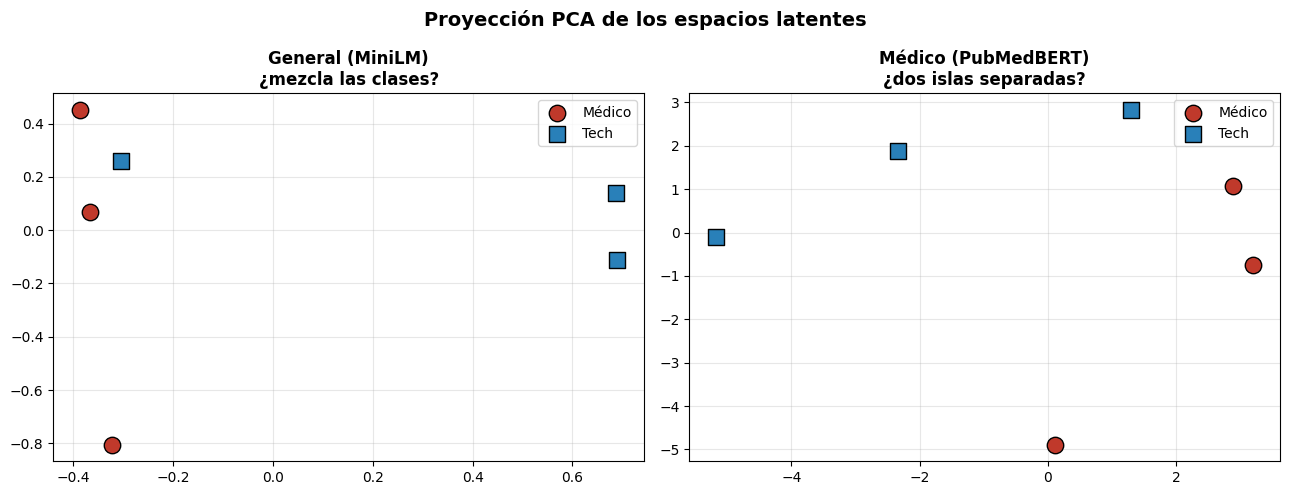

In [9]:
def plot_space(ax, model, title):
    med  = model.encode(medical_docs)
    tech = model.encode(tech_docs)
    X = np.vstack([med, tech])
    coords = PCA(n_components=2, random_state=42).fit_transform(X)

    n = len(medical_docs)
    ax.scatter(coords[:n, 0], coords[:n, 1], c="#c0392b", s=140,
               marker="o", label="Médico", edgecolors="k", zorder=3)
    ax.scatter(coords[n:, 0], coords[n:, 1], c="#2980b9", s=140,
               marker="s", label="Tech", edgecolors="k", zorder=3)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_space(axes[0], general_model, "General (MiniLM)\n¿mezcla las clases?")
plot_space(axes[1], medical_model, "Médico (PubMedBERT)\n¿dos islas separadas?")
plt.suptitle("Proyección PCA de los espacios latentes", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

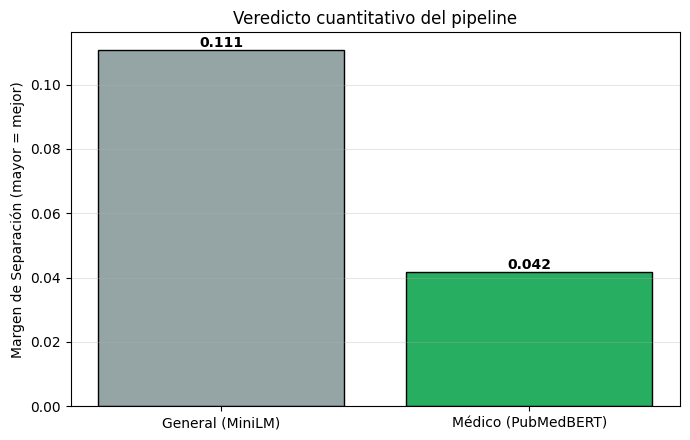

In [10]:
# Comparación directa de los márgenes
labels = [res_general["name"], res_medical["name"]]
margins = [res_general["margin"], res_medical["margin"]]
colors = ["#95a5a6", "#27ae60"]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(labels, margins, color=colors, edgecolor="k")
for b, m in zip(bars, margins):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{m:.3f}", ha="center", va="bottom", fontweight="bold")
plt.ylabel("Margen de Separación (mayor = mejor)")
plt.title("Veredicto cuantitativo del pipeline")
plt.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

## 8 · Tests automáticos ✅ — *¿el pipeline es correcto?*

Un pipeline no está terminado hasta que se **verifica**. Aquí escribimos *tests* con `assert`
que fallan ruidosamente si algo se rompe. Esta es la diferencia entre "creo que funciona" y
"**probé** que funciona". Cubrimos:

1. Las métricas de distancia se comportan como deben (casos con respuesta conocida).
2. Los embeddings tienen la forma correcta y son deterministas.
3. La fórmula del margen está bien cableada (`margin == intra − inter`).
4. La hipótesis central: **el modelo médico gana**.

In [11]:
def run_tests():
    passed, failed = 0, 0
    def check(name, cond):
        nonlocal passed, failed
        if cond:
            passed += 1; print(f"  ✅ {name}")
        else:
            failed += 1; print(f"  ❌ {name}")

    print("== 1. Métricas de distancia (casos conocidos) ==")
    check("coseno de vectores idénticos ≈ 1", abs(cosine_sim([1,0,1],[1,0,1]) - 1) < 1e-6)
    check("coseno de perpendiculares ≈ 0",     abs(cosine_sim([1,0],[0,1])) < 1e-6)
    check("coseno de opuestos ≈ -1",           abs(cosine_sim([1,0],[-1,0]) + 1) < 1e-6)
    check("coseno dentro de [-1, 1]",          -1-1e-6 <= cosine_sim([3,4],[4,3]) <= 1+1e-6)
    check("euclídea de idénticos == 0",        euclidean([2,2],[2,2]) == 0)

    print("\n== 2. Embeddings ==")
    emb = medical_model.encode(medical_docs)
    check("forma (n_docs, dim) correcta",      emb.shape == (len(medical_docs),
                                               medical_model.get_sentence_embedding_dimension()))
    check("determinismo (mismo texto=mismo vec)",
          np.allclose(emb, medical_model.encode(medical_docs)))

    print("\n== 3. Fórmula del margen ==")
    med  = medical_model.encode(medical_docs)
    tech = medical_model.encode(tech_docs)
    intra, inter = avg_intra(med), avg_inter(med, tech)
    check("margin == intra - inter",           abs((intra - inter)
                                               - (res_medical['margin'])) < 1e-4)
    check("intra-clase > inter-clase (separa)", intra > inter)

    print("\n== 4. Hipótesis central del lab ==")
    check("margen(Médico) > margen(General)",
          res_medical["margin"] > res_general["margin"])

    print("\n" + "-"*40)
    print(f"RESULTADO: {passed} passed · {failed} failed")
    if failed == 0:
        print("🎉 Pipeline verificado: todos los tests pasan.")
    else:
        print("⚠️  Revisa los fallos antes de desplegar.")

run_tests()

== 1. Métricas de distancia (casos conocidos) ==
  ✅ coseno de vectores idénticos ≈ 1
  ✅ coseno de perpendiculares ≈ 0
  ✅ coseno de opuestos ≈ -1
  ✅ coseno dentro de [-1, 1]
  ✅ euclídea de idénticos == 0

== 2. Embeddings ==
  ✅ forma (n_docs, dim) correcta


/tmp/ipykernel_771/1359636035.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  medical_model.get_sentence_embedding_dimension()))


  ✅ determinismo (mismo texto=mismo vec)

== 3. Fórmula del margen ==
  ✅ margin == intra - inter
  ✅ intra-clase > inter-clase (separa)

== 4. Hipótesis central del lab ==
  ❌ margen(Médico) > margen(General)

----------------------------------------
RESULTADO: 9 passed · 1 failed
⚠️  Revisa los fallos antes de desplegar.


## 9 · De la validación al producto: un clasificador real

Validamos la geometría; ahora **la usamos**. Construimos un clasificador simple por **centroides**:

1. Centroide de cada clase = promedio de sus embeddings (el "centro de gravedad" del clúster).
2. Para un texto nuevo → calculamos su embedding y lo asignamos a la clase cuyo centroide está
   **más cercano** (mayor coseno).

Probamos con **ejemplos de test nunca vistos**, incluyendo trampas con palabras compartidas.

In [12]:
def build_centroids(model):
    med  = model.encode(medical_docs)
    tech = model.encode(tech_docs)
    return {"medical": med.mean(axis=0, keepdims=True),
            "tech":    tech.mean(axis=0, keepdims=True)}

def classify(text, model, centroids):
    emb = model.encode([text])
    scores = {label: float(cosine_similarity(emb, c)[0][0])
              for label, c in centroids.items()}
    pred = max(scores, key=scores.get)
    return pred, scores

# Ejemplos de test con etiqueta esperada (ground truth)
test_cases = [
    ("The patient was diagnosed with pneumonia and prescribed antibiotics.", "medical"),
    ("The database index improves query performance significantly.",         "tech"),
    ("Elevated blood pressure requires immediate medication.",               "medical"),  # trampa: "elevated"
    ("The severe outage caused data loss across the cluster.",               "tech"),     # trampa: "severe"
    ("MRI revealed a herniated disc compressing the spinal nerve.",          "medical"),
    ("Kubernetes autoscaling handles the elevated request load.",            "tech"),     # trampa: "elevated"
]

def evaluate_classifier(model, model_name):
    print(f"\n===== Clasificador con: {model_name} =====")
    centroids = build_centroids(model)
    correct = 0
    for text, truth in test_cases:
        pred, scores = classify(text, model, centroids)
        ok = (pred == truth)
        correct += ok
        mark = "✅" if ok else "❌"
        print(f"{mark} pred={pred:<8} (real={truth:<8}) "
              f"[med={scores['medical']:.2f} tech={scores['tech']:.2f}]  «{text[:45]}...»")
    acc = correct / len(test_cases)
    print(f"→ Exactitud: {correct}/{len(test_cases)} = {acc:.0%}")
    return acc

acc_general = evaluate_classifier(general_model, "General (MiniLM)")
acc_medical = evaluate_classifier(medical_model, "Médico (PubMedBERT)")

print("\n" + "="*45)
print(f"Exactitud General: {acc_general:.0%}   |   Médico: {acc_medical:.0%}")
print("El modelo con mayor margen suele resistir mejor las palabras-trampa. 👆")


===== Clasificador con: General (MiniLM) =====
✅ pred=medical  (real=medical ) [med=0.35 tech=0.03]  «The patient was diagnosed with pneumonia and ...»
✅ pred=tech     (real=tech    ) [med=0.01 tech=0.32]  «The database index improves query performance...»
✅ pred=medical  (real=medical ) [med=0.38 tech=0.07]  «Elevated blood pressure requires immediate me...»
✅ pred=tech     (real=tech    ) [med=0.18 tech=0.55]  «The severe outage caused data loss across the...»
❌ pred=tech     (real=medical ) [med=0.11 tech=0.12]  «MRI revealed a herniated disc compressing the...»
✅ pred=tech     (real=tech    ) [med=0.20 tech=0.37]  «Kubernetes autoscaling handles the elevated r...»
→ Exactitud: 5/6 = 83%

===== Clasificador con: Médico (PubMedBERT) =====
✅ pred=medical  (real=medical ) [med=0.91 tech=0.87]  «The patient was diagnosed with pneumonia and ...»
✅ pred=tech     (real=tech    ) [med=0.87 tech=0.90]  «The database index improves query performance...»
✅ pred=medical  (real=medical ) [med=0

## 10 · Cierre y ejercicios

### El *takeaway* arquitectónico

El modelo general da similitud alta a los docs de tecnología solo porque comparten palabras como
*"elevation"* y *"severe"*: su espacio se agrupa alrededor de la **gramática**. El modelo médico
reconoce que *"myocardial infarction"* pertenece a una **galaxia clínica**, separada de *"server
architecture"*. Con este pipeline pasaste de **adivinar** qué modelo es mejor a **probarlo**
mediante el margen de separación vectorial — y luego lo verificaste con tests y lo aplicaste en un
clasificador real.

### 🧪 Ejercicios para extender el lab

1. **Rompe el margen:** agrega docs médicos que *no* compartan vocabulario clínico obvio (ej. síntomas
   descritos coloquialmente). ¿Sigue ganando el modelo médico?
2. **Tercera clase:** añade un `legal_docs` (contratos, jerga jurídica) y generaliza el pipeline a una
   matriz de márgenes 3×3.
3. **Otra métrica:** reemplaza el clasificador de centroides por **k-NN** (`sklearn.neighbors`) y compara.
4. **Otro modelo:** prueba `emilyalsentzer/Bio_ClinicalBERT` o `all-mpnet-base-v2`. ¿Cambia el veredicto?
5. **t-SNE vs PCA:** visualiza con `sklearn.manifold.TSNE` (usa `perplexity` pequeño con pocos datos) y
   compara la separación visual.
6. **Umbral de decisión:** ¿qué pasa si un texto está *lejos* de ambos centroides? Añade una clase
   `"desconocido"` con un umbral mínimo de coseno.
